# Day 2 — Linear Quadratic Regulator (LQR)

## Theory

The cart-pole system is inherently nonlinear which means that the equations of motion contain sin(θ) and cos(θ), which make standard linear analysis impossible.

However, near the upright equilibrium (θ = 0), these nonlinearities vanish to first order. We exploit this by **linearizing** the system around the equilibrium, producing a linear state-space model  ẋ = Ax + Bu  that is valid for small deviations.

With a linear model in hand, we can pose the stabilization problem as an
**optimization**. The Linear Quadratic Regulator (LQR) finds the control law
u = −Kx that minimizes the cost functional:

$$J = \int_0^{\infty} \mathbf{x}^T Q \mathbf{x} + u^T R u \; dt$$

where **Q** penalizes state deviations and **R** penalizes control effort. This
is not a heuristic — it is the provably optimal solution for linear systems under
quadratic cost. The gain matrix K is obtained by solving the **Algebraic Riccati
Equation (ARE)**:

$$A^T P + PA - PBR^{-1}B^T P + Q = 0$$

Once P is found, the optimal gain is  K = R⁻¹BᵀP.  The closed-loop system
ẋ = (A − BK)x is then guaranteed to be stable, provided Q ≥ 0 and R > 0.

The state vector throughout is  **x = [x,  ẋ,  θ,  θ̇]**  and the single
control input is the horizontal force F applied to the cart.

### Cell 1 — Imports
All libraries needed for the notebook. `sympy` for symbolic math, `numpy` and
`scipy` for numerical computation, `matplotlib` for verification plots.
`scipy.linalg.solve_continuous_are` is the key function that solves the Riccati
equation in one call.

In [3]:
import sympy as sp
import numpy as np
from scipy.linalg import solve_continuous_are
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

### Cell 2 — Symbolic EOM
Re-derives the equations of motion symbolically using the Lagrangian, with system
parameters kept as sympy symbols. This gives us the exact nonlinear accelerations
ẍ and θ̈ as functions of the full state — the same physics as Day 1, but now in
symbolic form so we can differentiate them.

In [4]:
# --- symbols ---
x, xd, th, thd = sp.symbols('x xd th thd')
F = sp.symbols('F')
M, m, L, g = sp.symbols('M m L g')

# --- kinetic energy ---
# cart
T_cart = sp.Rational(1,2) * M * xd**2

# pole tip position
x_pole = x + L * sp.sin(th)
y_pole = L * sp.cos(th)

vx_pole = xd + L * thd * sp.cos(th)
vy_pole = -L * thd * sp.sin(th)

T_pole = sp.Rational(1,2) * m * (vx_pole**2 + vy_pole**2)
T = sp.simplify(T_cart + T_pole)

# --- potential energy ---
V = m * g * L * sp.cos(th)

# --- Lagrangian ---
Lag = T - V

# --- EOM via Euler-Lagrange ---
# d/dt(∂L/∂ẋ) - ∂L/∂x = F - (1)
# d/dt(∂L/∂θ̇) - ∂L/∂θ = 0 - (2)

# for x:
dL_dxd  = sp.diff(Lag, xd)
dL_dx   = sp.diff(Lag, x)
# treating xdd, thdd as new symbols for the implicit EOM
xdd, thdd = sp.symbols('xdd thdd')
dt_dL_dxd = dL_dxd.diff(x)*xd + dL_dxd.diff(xd)*xdd + dL_dxd.diff(th)*thd + dL_dxd.diff(thd)*thdd
eq1 = sp.Eq(dt_dL_dxd - dL_dx, F) # eq (1)

# for theta:
dL_dthd = sp.diff(Lag, thd)
dL_dth  = sp.diff(Lag, th)
dt_dL_dthd = dL_dthd.diff(x)*xd + dL_dthd.diff(xd)*xdd + dL_dthd.diff(th)*thd + dL_dthd.diff(thd)*thdd
eq2 = sp.Eq(dt_dL_dthd - dL_dth, 0) # eq (2)

# --- solve for xdd and thdd ---
sol = sp.solve([eq1, eq2], [xdd, thdd])
xdd_expr  = sp.simplify(sol[xdd])
thdd_expr = sp.simplify(sol[thdd])

print("ẍ  =", xdd_expr)
print()
print("θ̈  =", thdd_expr)

ẍ  = (F + L*m*thd**2*sin(th) - g*m*sin(2*th)/2)/(M + m*sin(th)**2)

θ̈  = (-F*cos(th) - L*m*thd**2*sin(2*th)/2 + M*g*sin(th) + g*m*sin(th))/(L*(M + m*sin(th)**2))


### Cell 3 — Jacobian → A and B matrices

How to Linearize the forcing function??

Given a nonlinear system:
$$\dot{\mathbf{x}} = f(\mathbf{x}, u)$$
where $\mathbf{x} = [x, \dot{x}, \theta, \dot{\theta}]$ is the state vector and $u = F$ is the input (force on cart).

### 1. Choose an Equilibrium Point
For the upright balanced position:
$$\mathbf{x}_0 = [0, 0, 0, 0], \quad u_0 = 0$$

### 2. Taylor Series Expansion
Expanding $f$ around the equilibrium point and keeping only first-order terms. The matrix A and B are the jacobian matrices:
$$\dot{\mathbf{x}} \approx \underbrace{\left.\frac{\partial f}{\partial \mathbf{x}}\right|_{\mathbf{x}_0}}_{A} \cdot \mathbf{x} + \underbrace{\left.\frac{\partial f}{\partial u}\right|_{\mathbf{x}_0}}_{B} \cdot u$$

### 3. State-Space Form
This yields the linear state-space representation:
$$\dot{\mathbf{x}} = A\mathbf{x} + Bu$$

In [5]:
# --- state vector and input ---
state = [x, xd, th, thd]

# --- the state derivatives (ẋ = f(state, F)) ---
# [xd, xdd, thd, thdd]
f = sp.Matrix([
    xd,
    xdd_expr,
    thd,
    thdd_expr
])

# --- Jacobian w.r.t state → A matrix ---
A_sym = f.jacobian(state) #Here We have calculated the general Jacobian matrix

# --- Jacobian w.r.t input F → B matrix ---
B_sym = f.jacobian([F]) #Here We have calculated the general Jacobian matrix w.r.t input F

# --- evaluate at equilibrium: x=0, xd=0, th=0, thd=0, F=0 ---
eq_point = {x: 0, xd: 0, th: 0, thd: 0, F: 0}

# evaluate A and B at the equilibrium point (That is the taylor expansion around the point)
A_lin = sp.simplify(A_sym.subs(eq_point))
B_lin = sp.simplify(B_sym.subs(eq_point))

print("A (symbolic, at equilibrium):")
sp.pprint(A_lin)
print()
print("B (symbolic, at equilibrium):")
sp.pprint(B_lin)

A (symbolic, at equilibrium):
⎡0  1      0      0⎤
⎢                  ⎥
⎢        -g⋅m      ⎥
⎢0  0    ─────    0⎥
⎢          M       ⎥
⎢                  ⎥
⎢0  0      0      1⎥
⎢                  ⎥
⎢      g⋅(M + m)   ⎥
⎢0  0  ─────────  0⎥
⎣         L⋅M      ⎦

B (symbolic, at equilibrium):
⎡ 0 ⎤
⎢   ⎥
⎢ 1 ⎥
⎢ ─ ⎥
⎢ M ⎥
⎢   ⎥
⎢ 0 ⎥
⎢   ⎥
⎢-1 ⎥
⎢───⎥
⎣L⋅M⎦


### Cell 4 — Substitute numerical values
Plugs in M=1.0, m=0.3, L=0.8, g=9.81 into the symbolic A and B to get concrete
numerical matrices. Prints them out so we can inspect the structure — this is the
model the LQR controller will actually use.

In [6]:
# --- numerical values ---
params = {M: 1.0, m: 0.3, L: 0.8, g: 9.81}

# --- substitute into symbolic A and B ---
A_num = np.array(A_lin.subs(params).tolist(), dtype=float)
B_num = np.array(B_lin.subs(params).tolist(), dtype=float)

print("A =")
print(np.round(A_num, 4))
print()
print("B =")
print(np.round(B_num, 4))

A =
[[ 0.      1.      0.      0.    ]
 [ 0.      0.     -2.943   0.    ]
 [ 0.      0.      0.      1.    ]
 [ 0.      0.     15.9412  0.    ]]

B =
[[ 0.  ]
 [ 1.  ]
 [ 0.  ]
 [-1.25]]


### Cell 5 — Open-loop eigenvalue check
Computes the eigenvalues of A. At least one eigenvalue will have a positive real
part, confirming the system is unstable without control — the pole will fall. This
is the mathematical proof of what we felt trying to balance it manually in pygame.

In [7]:
eigenvalues = np.linalg.eigvals(A_num)

print("Open-loop eigenvalues of A:")
for ev in eigenvalues:
    print(f"  {ev:.4f}")

print()
if any(ev.real > 0 for ev in eigenvalues):
    print("✗ Unstable — at least one eigenvalue has positive real part")
else:
    print("✓ Stable")

Open-loop eigenvalues of A:
  0.0000
  0.0000
  3.9926
  -3.9926

✗ Unstable — at least one eigenvalue has positive real part


### Cell 6 — Choose Q and R (Bryson's Rule)
Sets the cost matrices using Bryson's Rule: each diagonal entry of Q is
1/(max acceptable deviation)² for that state, and R is 1/F_max². These choices
are physically motivated — a state at its maximum tolerable value contributes
exactly 1 to the cost.

In [8]:
# --- maximum acceptable values for each state ---
x_max   = 2.0          # cart position  — okay up to 2 m from center
xd_max  = 5.0          # cart velocity  — okay up to 5 m/s
th_max  = 20 * np.pi/180   # pole angle — okay up to 20 degrees
thd_max = 10 * np.pi/180   # pole rate  — okay up to 10 degrees/s

F_max   = 15.0         # max force — 15 N

# --- Bryson's Rule ---
Q = np.diag([
    1/x_max**2,
    1/xd_max**2,
    1/th_max**2,
    1/thd_max**2
])

R = np.array([[1/F_max**2]])

print("Q =")
print(np.round(Q, 4))
print()
print(f"R = {R[0,0]:.6f}")
print()
print("Diagonal of Q (weights per state):")
labels = ['x', 'xd', 'theta', 'thetad']
for label, w in zip(labels, np.diag(Q)):
    print(f"  {label:8s} weight = {w:.4f}")

Q =
[[ 0.25    0.      0.      0.    ]
 [ 0.      0.04    0.      0.    ]
 [ 0.      0.      8.207   0.    ]
 [ 0.      0.      0.     32.8281]]

R = 0.004444

Diagonal of Q (weights per state):
  x        weight = 0.2500
  xd       weight = 0.0400
  theta    weight = 8.2070
  thetad   weight = 32.8281


### Cell 7 — Solve Riccati → compute K
Calls scipy.linalg.solve_continuous_are(A, B, Q, R) to solve the Algebraic
Riccati Equation for P, then computes K = R⁻¹BᵀP. Prints the four gain values —
each one multiplies a state variable to produce the control force F = −Kx.

In [9]:
# --- solve the Algebraic Riccati Equation ---
P = solve_continuous_are(A_num, B_num, Q, R)

# --- compute optimal gain matrix ---
K = np.linalg.inv(R) @ B_num.T @ P

print("P =")
print(np.round(P, 4))
print()
print("K =")
print(np.round(K, 4))
print()
print("Individual gains:")
labels = ['x', 'xd', 'theta', 'thetad']
for label, k in zip(labels, K[0]):
    print(f"  k_{label:6s} = {k:.4f}")

P =
[[ 0.5664  0.6217  3.3773  0.524 ]
 [ 0.6217  1.0643  7.128   0.9119]
 [ 3.3773  7.128  73.4447  6.3983]
 [ 0.524   0.9119  6.3983  1.0897]]

K =
[[  -7.5     -16.993  -195.7174 -101.3191]]

Individual gains:
  k_x      = -7.5000
  k_xd     = -16.9930
  k_theta  = -195.7174
  k_thetad = -101.3191


### Cell 8 — Closed-loop eigenvalue check
Computes eigenvalues of (A − BK). All eigenvalues must have negative real parts
for stability. This is the verification step — if these are all in the left half
of the complex plane, the controller is mathematically guaranteed to stabilize
the system.

In [10]:
# --- closed loop system matrix ---
A_cl = A_num - B_num @ K

eigenvalues_cl = np.linalg.eigvals(A_cl)

print("Closed-loop eigenvalues of (A - BK):")
for ev in eigenvalues_cl:
    print(f"  {ev:.4f}")

print()
if all(ev.real < 0 for ev in eigenvalues_cl):
    print("✓ Stable — all eigenvalues in left half plane")
else:
    print("✗ Unstable — something is wrong with K")

print()
print("Open-loop vs Closed-loop:")
print(f"  Unstable open-loop pole:  +{3.9926:.4f}")
print(f"  Replaced by closed-loop poles with real parts:",
      [round(ev.real, 4) for ev in eigenvalues_cl])

Closed-loop eigenvalues of (A - BK):
  -107.6183+0.0000j
  -0.5410+0.7757j
  -0.5410-0.7757j
  -0.9555+0.0000j

✓ Stable — all eigenvalues in left half plane

Open-loop vs Closed-loop:
  Unstable open-loop pole:  +3.9926
  Replaced by closed-loop poles with real parts: [-107.6183, -0.541, -0.541, -0.9555]


### Cell 9 — Closed-loop simulation + plot
Runs solve_ivp with the LQR controller active (F = −Kx computed every step) from
a slightly perturbed initial condition. Plots x, θ, and F over time — you should
see both states decay to zero, confirming the controller works before we ever
touch pygame.

/var/folders/vf/bzx8bd294n11t5xg0hxttp1h0000gn/T/ipykernel_37276/4180327504.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F_v = float(-K @ np.array(state))
/var/folders/vf/bzx8bd294n11t5xg0hxttp1h0000gn/T/ipykernel_37276/4180327504.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F_t = np.array([-float(K @ sol.y[:, i]) for i in range(len(t))])


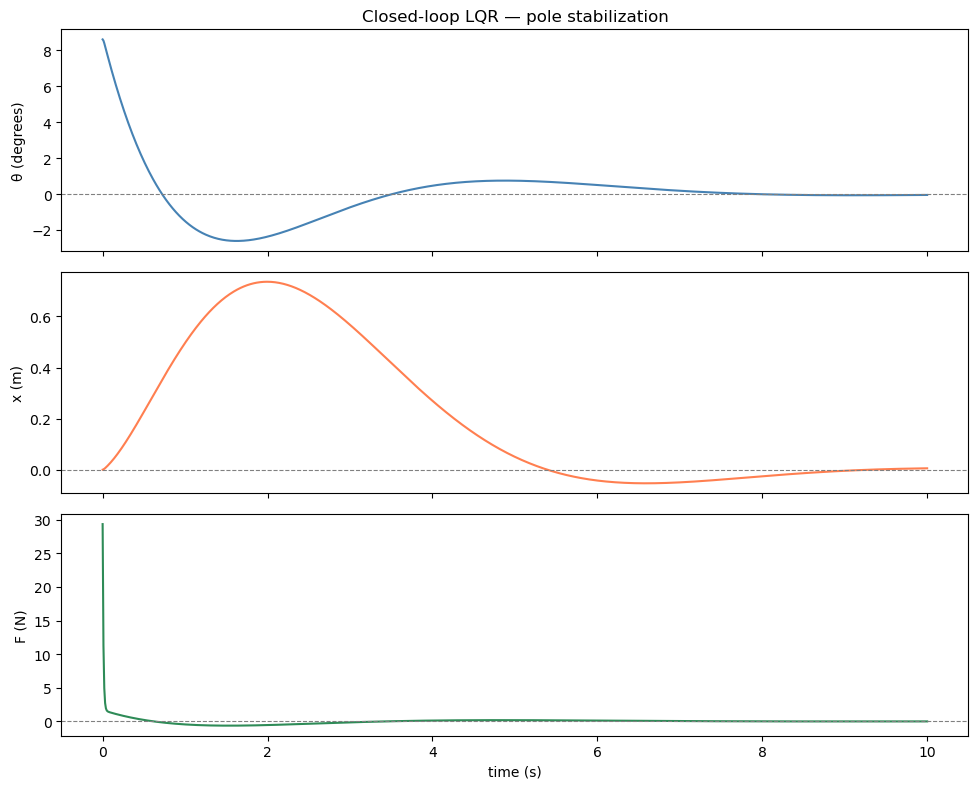


Final angle : -0.052698 deg
Final position : 0.005387 m
Peak force : 29.3576 N


In [ ]:
# --- initial condition: pole slightly tilted ---
x0 = [0.0, 0.0, 0.15, 0.0]   # 0.15 rad ≈ 8.6 degrees tilt

# --- closed loop dynamics ---
def dynamics_cl(t, state):
    x_v, xd_v, th_v, thd_v = state

    # LQR control law
     #it calculates the force requires using the current state and the gain matrix K
    F_v = float(-K @ np.array(state))

    # nonlinear EOM (same as Day 1)
    M_v, m_v, L_v, g_v = 1.0, 0.3, 0.8, 9.81
    denom = M_v + m_v * np.sin(th_v)**2 #denom = denomiator
    xdd  = (F_v + m_v*np.sin(th_v)*(L_v*thd_v**2 - g_v*np.cos(th_v))) / denom
    thdd = (-F_v*np.cos(th_v) - m_v*L_v*thd_v**2*np.sin(th_v)*np.cos(th_v)
            + (M_v + m_v)*g_v*np.sin(th_v)) / (L_v * denom)

    return [xd_v, xdd, thd_v, thdd]

# --- simulate ---
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)
sol = solve_ivp(dynamics_cl, t_span, x0, t_eval=t_eval, max_step=0.01)

# --- extract ---
t   = sol.t
x_t = sol.y[0]
th_t = sol.y[2]
F_t = np.array([-float(K @ sol.y[:, i]) for i in range(len(t))])

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, np.degrees(th_t), color='steelblue')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('θ (degrees)')
axes[0].set_title('Closed-loop LQR — pole stabilization')

axes[1].plot(t, x_t, color='coral')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('x (m)')

axes[2].plot(t, F_t, color='seagreen')
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[2].set_ylabel('F (N)')
axes[2].set_xlabel('time (s)')

plt.tight_layout()
plt.show()

print(f"\nFinal angle : {np.degrees(th_t[-1]):.6f} deg")
print(f"Final position : {x_t[-1]:.6f} m")
print(f"Peak force : {np.max(np.abs(F_t)):.4f} N")